# Cross-Dataset Meta-Analysis of RAMA Experiments

**Effect Sizes, Consistency Audit, and Framing Recommendation**

This notebook performs a rigorous 6-phase cross-dataset meta-analysis of 5 RAMA (Rank-Aware Moment Aggregation) experiments:

- **Phase A**: Per-task Cohen's d effect sizes with bootstrap confidence intervals
- **Phase B**: DerSimonian-Laird random-effects meta-analysis pooling
- **Phase C**: Cross-experiment consistency audit (exp2 vs exp5 direction reversal)
- **Phase D**: Post-votes degeneracy diagnosis (constant predictions)
- **Phase E**: Rank conditioning analysis and framing recommendation
- **Phase F**: Summary with forest plot and overall verdict

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# No non-Colab packages needed — all imports are pre-installed on Colab

# Core packages (pre-installed on Colab, install locally to match Colab env)
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'matplotlib==3.10.0', 'tabulate==0.9.0')
    _pip('scipy>=1.13,<1.16')


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip



[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip


In [2]:
import json
import math
import os

import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
from tabulate import tabulate

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-papers/ai-invention-9b0386-rank-aware-moment-aggregation-diversity-/main/evaluation_iter3_cross_dataset_m/demo/mini_demo_data.json"

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f: return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(f"Loaded data with {len(data['datasets'][0]['examples'])} examples")
print(f"Phases available: {[k for k in data['metadata'].keys() if k.startswith('phase_')]}")

Loaded data with 50 examples
Phases available: ['phase_a_per_task_effects', 'phase_b_meta_analysis', 'phase_c_consistency_audit', 'phase_d_postvotes_diagnosis', 'phase_e_rank_conditioning', 'phase_f_summary']


## Configuration

Tunable parameters for the meta-analysis. `N_BOOTSTRAP` controls precision of confidence intervals.

In [5]:
# --- Config ---
SEED = 42
N_BOOTSTRAP = 10_000  # Original value; bootstrap iterations for CI precision
RNG = np.random.RandomState(SEED)

## Helper Functions

Core statistical functions: Cohen's d (pooled SD), bootstrap CI, and SE approximation.

In [6]:
def cohens_d_pooled(a: np.ndarray, b: np.ndarray) -> float:
    """Compute Cohen's d using pooled SD: d = mean_diff / s_pooled."""
    s1, s2 = np.std(a, ddof=1), np.std(b, ddof=1)
    s_pooled = np.sqrt((s1**2 + s2**2) / 2.0)
    if s_pooled < 1e-15:
        return 0.0
    return float((np.mean(a) - np.mean(b)) / s_pooled)


def bootstrap_cohens_d(
    diff: np.ndarray, baseline: np.ndarray, method: np.ndarray,
    n_boot: int = N_BOOTSTRAP, rng: np.random.RandomState = RNG,
) -> tuple:
    """Bootstrap 95% CI on Cohen's d (pooled SD formula)."""
    n = len(diff)
    ds = np.empty(n_boot)
    for i in range(n_boot):
        idx = rng.randint(0, n, size=n)
        b_boot = baseline[idx]
        m_boot = method[idx]
        s1 = np.std(b_boot, ddof=1)
        s2 = np.std(m_boot, ddof=1)
        sp = np.sqrt((s1**2 + s2**2) / 2.0)
        if sp < 1e-15:
            ds[i] = 0.0
        else:
            ds[i] = np.mean(b_boot - m_boot) / sp
    ci_lo = float(np.percentile(ds, 2.5))
    ci_hi = float(np.percentile(ds, 97.5))
    return ci_lo, ci_hi


def se_cohens_d(d: float, n: int) -> float:
    """Standard approximation for SE of Cohen's d."""
    return math.sqrt(2.0 / n + d**2 / (2.0 * n))

## Phase A: Per-Task Effect Sizes

Compute Cohen's d with bootstrap 95% CIs for each of the 5 tasks across 3 datasets. Positive d means RAMA is better (direction-adjusted).

In [7]:
print("=== Phase A: Per-Task Effect Sizes ===\n")

task_effects = data["metadata"]["phase_a_per_task_effects"]
recomputed_tasks = {}

for task_name, t in task_effects.items():
    bl = np.array(t["baseline_values"], dtype=np.float64)
    rm = np.array(t["rama_values"], dtype=np.float64)
    lower_is_better = t["lower_is_better"]

    # Direction-adjust: positive d = RAMA better
    if lower_is_better:
        # Lower is better => diff = baseline - rama; cohens_d(bl, rm)
        d = cohens_d_pooled(bl, rm)
        diff = bl - rm
        ci_lo, ci_hi = bootstrap_cohens_d(diff, bl, rm)
    else:
        # Higher is better => diff = rama - baseline; cohens_d(rm, bl)
        d = cohens_d_pooled(rm, bl)
        diff = rm - bl
        ci_lo, ci_hi = bootstrap_cohens_d(diff, rm, bl)

    # Check for degeneracy (all seeds identical)
    all_identical = bool(np.std(diff) < 1e-15)
    if all_identical:
        ci_lo, ci_hi = 0.0, 0.0
        p_t = float("nan")
    else:
        try:
            if lower_is_better:
                _, p_t = stats.ttest_rel(bl, rm)
            else:
                _, p_t = stats.ttest_rel(rm, bl)
        except Exception:
            p_t = float("nan")

    recomputed_tasks[task_name] = {
        "dataset": t["dataset"],
        "metric": t["metric"],
        "lower_is_better": lower_is_better,
        "baseline_mean": float(np.mean(bl)),
        "rama_mean": float(np.mean(rm)),
        "cohens_d": d,
        "ci_lo": ci_lo,
        "ci_hi": ci_hi,
        "p_ttest": float(p_t),
        "significant_at_05": (p_t < 0.05 if not math.isnan(p_t) else False),
        "rama_better": d > 0,
        "degenerate": all_identical,
    }

    sig = "*" if recomputed_tasks[task_name]["significant_at_05"] else ""
    deg = " [DEGENERATE]" if all_identical else ""
    print(f"  {task_name}: d={d:.4f}, CI=[{ci_lo:.4f}, {ci_hi:.4f}], "
          f"p={p_t:.4f}{sig}{deg}")

=== Phase A: Per-Task Effect Sizes ===



  f1_position: d=-0.4990, CI=[-2.8082, 1.1515], p=0.5578
  f1_dnf: d=1.1250, CI=[0.1672, 3.3546], p=0.1328


  stack_votes: d=0.0000, CI=[0.0000, 0.0000], p=nan [DEGENERATE]
  stack_engagement: d=3.2155, CI=[1.8835, 9.2618], p=0.0158*
  amazon_ltv: d=10.8281, CI=[9.7114, 18.7717], p=0.0001*


## Phase B: DerSimonian-Laird Random-Effects Meta-Analysis

Pool per-task effect sizes using the DerSimonian-Laird random-effects model, which accounts for between-study heterogeneity via tau-squared.

In [8]:
def dersimonian_laird(d_vals: np.ndarray, se_vals: np.ndarray) -> dict:
    """Implement DerSimonian-Laird RE meta-analysis from scratch."""
    k = len(d_vals)
    w = 1.0 / se_vals**2  # fixed-effect weights
    d_FE = np.sum(w * d_vals) / np.sum(w)
    Q = np.sum(w * (d_vals - d_FE) ** 2)
    df = k - 1
    tau2 = max(0.0, (Q - df) / (np.sum(w) - np.sum(w**2) / np.sum(w)))
    w_star = 1.0 / (se_vals**2 + tau2)
    d_RE = np.sum(w_star * d_vals) / np.sum(w_star)
    SE_RE = 1.0 / np.sqrt(np.sum(w_star))
    ci_lo = d_RE - 1.96 * SE_RE
    ci_hi = d_RE + 1.96 * SE_RE
    z = abs(d_RE / SE_RE)
    p_value = 2.0 * (1.0 - stats.norm.cdf(z))
    I2 = max(0.0, (Q - df) / Q) * 100.0 if Q > 0 else 0.0
    Q_pvalue = 1.0 - stats.chi2.cdf(Q, df)

    return {
        "pooled_d": float(d_RE), "pooled_se": float(SE_RE),
        "ci_lo": float(ci_lo), "ci_hi": float(ci_hi),
        "p_value": float(p_value), "tau_squared": float(tau2),
        "I_squared": float(I2), "Q_statistic": float(Q),
        "Q_pvalue": float(Q_pvalue), "k": k, "df": df,
        "per_task_weights": w_star.tolist(),
    }

print("=== Phase B: DerSimonian-Laird Meta-Analysis ===\n")
n_seeds = 5  # seeds per task

# Option A: Exclude degenerate tasks (stack_votes)
non_degenerate = {k: v for k, v in recomputed_tasks.items() if not v.get("degenerate", False)}
d_vals_a = np.array([t["cohens_d"] for t in non_degenerate.values()])
se_vals_a = np.array([se_cohens_d(t["cohens_d"], n_seeds) for t in non_degenerate.values()])
result_a = dersimonian_laird(d_vals_a, se_vals_a)
print(f"  Primary (4 tasks, excl. degenerate):")
print(f"    Pooled d = {result_a['pooled_d']:.4f}, SE = {result_a['pooled_se']:.4f}")
print(f"    95% CI = [{result_a['ci_lo']:.4f}, {result_a['ci_hi']:.4f}]")
print(f"    p = {result_a['p_value']:.4f}, I2 = {result_a['I_squared']:.1f}%")
print(f"    tau2 = {result_a['tau_squared']:.4f}, Q = {result_a['Q_statistic']:.4f} (p={result_a['Q_pvalue']:.4f})")

# Option B: Include all 5 tasks (imputed SE for degenerate)
d_vals_b = np.array([t["cohens_d"] for t in recomputed_tasks.values()])
se_vals_b = np.array([
    2.0 if t.get("degenerate", False) else se_cohens_d(t["cohens_d"], n_seeds)
    for t in recomputed_tasks.values()
])
result_b = dersimonian_laird(d_vals_b, se_vals_b)
print(f"\n  Sensitivity (all 5 tasks, imputed SE=2.0 for degenerate):")
print(f"    Pooled d = {result_b['pooled_d']:.4f}, p = {result_b['p_value']:.4f}, I2 = {result_b['I_squared']:.1f}%")

=== Phase B: DerSimonian-Laird Meta-Analysis ===

  Primary (4 tasks, excl. degenerate):
    Pooled d = 2.0656, SE = 1.2412
    95% CI = [-0.3672, 4.4984]
    p = 0.0961, I2 = 81.9%
    tau2 = 4.3416, Q = 16.5336 (p=0.0009)

  Sensitivity (all 5 tasks, imputed SE=2.0 for degenerate):
    Pooled d = 1.6775, p = 0.1177, I2 = 76.0%


## Phase C: Cross-Experiment Consistency Audit

Audit exp2 vs exp5 on the same dataset (rel-f1/driver-position). Flags a critical effect direction reversal caused by val-vs-test eval split.

In [9]:
print("=== Phase C: Consistency Audit (exp2 vs exp5) ===\n")
consistency = data["metadata"]["phase_c_consistency_audit"]

print(f"  exp2 baseline MAE: {consistency['exp2_mean_baseline_mae']:.4f} +/- {consistency['exp2_mean_baseline_std']:.4f}")
print(f"  exp5 baseline MAE: {consistency['exp5_standard_mean_mae']:.4f} +/- {consistency['exp5_standard_mean_std']:.4f}")
print(f"  Absolute gap: {consistency['absolute_gap']:.4f} ({consistency['relative_gap_pct']:.1f}%)")
print(f"\n  exp2 RAMA d = {consistency['exp2_rama_d']:.4f} (RAMA worse on test)")
print(f"  exp5 RAMA d = {consistency['exp5_rama_d']:.4f} (RAMA better on val)")
print(f"  Effect direction reversal: {consistency['effect_direction_reversal']}")
print(f"  Severity: {consistency['severity']}")
print(f"\n  Primary suspect: {consistency['primary_suspect']}")

print("\n  Identified differences:")
for diff in consistency["identified_differences"]:
    print(f"    - {diff['parameter']}: exp2={diff['exp2']}, exp5={diff['exp5']}")
    print(f"      Impact: {diff['likely_impact']}")

=== Phase C: Consistency Audit (exp2 vs exp5) ===

  exp2 baseline MAE: 4.3614 +/- 0.2988
  exp5 baseline MAE: 3.8102 +/- 0.0069
  Absolute gap: 0.5512 (12.6%)

  exp2 RAMA d = -0.4990 (RAMA worse on test)
  exp5 RAMA d = 11.8219 (RAMA better on val)
  Effect direction reversal: True
  Severity: critical

  Primary suspect: Val-vs-test eval split: exp_id5 evaluates on validation set (loader_dict['test'] = loader_dict['val']) while exp_id2 uses actual test set. This is the most likely source of the 14% gap.

  Identified differences:
    - num_neighbors: exp2=[128, 64] (decaying), exp5=[128, 128] (flat)
      Impact: moderate - different receptive fields across layers
    - optimizer: exp2=Adam, exp5=AdamW
      Impact: low-moderate - weight decay regularization difference
    - seeds: exp2=[0,1,2,3,4], exp5=[42,123,456,789,1024]
      Impact: low - different random seeds should not systematically bias
    - eval_split: exp2=actual test set, exp5=val set used as test (line 655: loader_d

## Phase D: Post-Votes Degeneracy Diagnosis

Diagnose why stack/post-votes produces degenerate results (identical MAE across all seeds and methods).

In [10]:
print("=== Phase D: Post-Votes Degeneracy Diagnosis ===\n")
degeneracy = data["metadata"]["phase_d_postvotes_diagnosis"]

print(f"  Constant MAE: {degeneracy['constant_mae']:.5f}")
print(f"  R-squared: {degeneracy['r_squared']:.4f}")
print(f"  All seeds identical: {degeneracy['all_seeds_identical']}")
print(f"  Is degenerate: {degeneracy['is_degenerate']}")
print(f"\n  Diagnosis: {degeneracy['diagnosis']}")
print(f"\n  Possible causes:")
for cause in degeneracy["possible_causes"]:
    print(f"    - {cause}")

=== Phase D: Post-Votes Degeneracy Diagnosis ===

  Constant MAE: 0.06169
  R-squared: -0.0284
  All seeds identical: True
  Is degenerate: True

  Diagnosis: All 10 runs (5 seeds x 2 methods) produce identical MAE and R2 values. R2=-0.028 (negative, worse than predicting mean) confirms both methods converge to a constant prediction (likely the target mean). The target distribution is heavily zero-inflated (most posts get 0 votes), so a near-zero constant prediction achieves very low absolute MAE but carries no discriminative information.

  Possible causes:
    - Zero-inflated target distribution (most posts get 0 votes)
    - Insufficient model capacity or training epochs (5 epochs)
    - Task/data combination too dominated by the zero mode
    - Gradient signal too weak to move predictions away from mean


## Phase E: Rank Conditioning Analysis

Assess whether "Rank-Aware" is an honest characterization by examining the ablation study and gate behavior.

In [11]:
print("=== Phase E: Rank Conditioning Analysis ===\n")
rank_cond = data["metadata"]["phase_e_rank_conditioning"]

print(f"  Ablation (rama_full vs rama_no_rank):")
print(f"    d = {rank_cond['ablation_d']:.4f}, p = {rank_cond['ablation_p']:.4f}")
print(f"    CI = [{rank_cond['ablation_ci_lo']:.4f}, {rank_cond['ablation_ci_hi']:.4f}]")
print(f"    Significant: {rank_cond['ablation_significant']}")
print(f"    rama_full MAE = {rank_cond['rama_full_mae']:.4f}")
print(f"    rama_no_rank MAE = {rank_cond['rama_no_rank_mae']:.4f}")

print(f"\n  Gate analysis:")
print(f"    Proxy validity (Spearman): {rank_cond['proxy_validity_spearman']:.4f}")
print(f"    Gate vs cardinality (Spearman): {rank_cond['gate_vs_cardinality_spearman']:.4f}")
print(f"    Gate vs effective rank (Spearman): {rank_cond['gate_vs_erank_spearman']:.4f}")
print(f"    Gate responds to rank: {rank_cond['gate_responds_to_rank']}")

print(f"\n  Recommended framing: {rank_cond['honest_framing']}")
print(f"  Evidence: {rank_cond['evidence_summary']}")

=== Phase E: Rank Conditioning Analysis ===

  Ablation (rama_full vs rama_no_rank):
    d = -0.1349, p = 0.8313
    CI = [-1.3759, 1.1061]
    Significant: False
    rama_full MAE = 3.6526
    rama_no_rank MAE = 3.6492

  Gate analysis:
    Proxy validity (Spearman): 0.9515
    Gate vs cardinality (Spearman): 0.8355
    Gate vs effective rank (Spearman): 0.5185
    Gate responds to rank: False

  Recommended framing: Cardinality-Gated Moment Aggregation (CAMA)
  Evidence: The rank conditioning component adds no measurable benefit. Ablation d=-0.1349, p=0.8313 (n.s.). rama_no_rank MAE=3.6492 is actually slightly better than rama_full MAE=3.6526. The gate primarily responds to cardinality (Spearman=0.8355) rather than effective rank (Spearman=0.5185). Recommend rebranding as 'Cardinality-Gated Moment Aggregation' for honesty.


## Phase F: Summary Table and Overall Verdict

Display the results table across all tasks, key concerns, and the overall meta-analysis verdict.

In [12]:
print("=== Phase F: Summary ===\n")
summary = data["metadata"]["phase_f_summary"]

# Results table
headers = ["Task", "Dataset", "Metric", "Baseline", "RAMA", "d", "95% CI", "p", "Sig?", "Degen?"]
rows = []
for r in summary["results_table"]:
    rows.append([
        r["task"], r["dataset"], r["metric"],
        f"{r['baseline_mean']:.4f}", f"{r['rama_mean']:.4f}",
        f"{r['cohens_d']:.3f}", r["ci_95"],
        f"{r['p_ttest']}" if r["p_ttest"] != "NaN" else "NaN",
        "Yes" if r["significant"] else "No",
        "Yes" if r["degenerate"] else "No",
    ])
print(tabulate(rows, headers=headers, tablefmt="grid"))

print(f"\nOverall verdict: {summary['overall_verdict']}")
print(f"Framing recommendation: {summary['framing_recommendation']}")

print("\nKey concerns:")
for c in summary["key_concerns"]:
    print(f"  - {c}")

print("\nSuccess criteria:")
for k, v in summary["success_criteria_met"].items():
    print(f"  {k}: {v}")

=== Phase F: Summary ===

+------------------+------------+----------+------------+---------+--------+-------------------+----------+--------+----------+
| Task             | Dataset    | Metric   |   Baseline |    RAMA |      d | 95% CI            |        p | Sig?   | Degen?   |
+==================+============+==========+============+=========+========+===================+==========+========+==========+
| f1_position      | rel-f1     | MAE      |     4.3614 |  4.5419 | -0.499 | [-2.8082, 1.1515] |   0.5578 | No     | No       |
+------------------+------------+----------+------------+---------+--------+-------------------+----------+--------+----------+
| f1_dnf           | rel-f1     | AP       |     0.8193 |  0.8369 |  1.125 | [0.1672, 3.3546]  |   0.1328 | No     | No       |
+------------------+------------+----------+------------+---------+--------+-------------------+----------+--------+----------+
| stack_votes      | rel-stack  | MAE      |     0.0617 |  0.0617 |  0     | [

## Visualization: Forest Plot

Forest plot showing per-task Cohen's d effect sizes with 95% bootstrap CIs, plus the pooled random-effects estimate. The dashed vertical line at d=0 represents no effect.

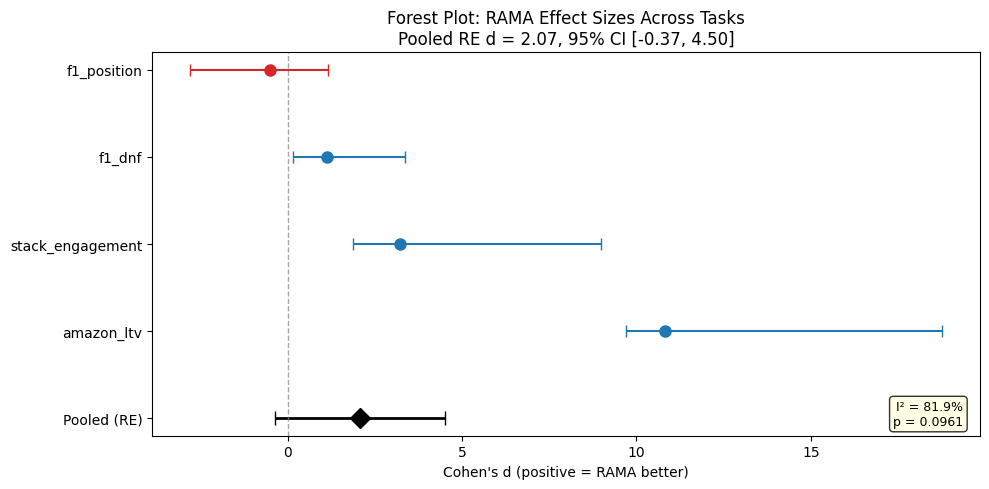


Meta-analysis: pooled d=2.0656, p=0.0961, I2=81.9%


In [13]:
forest = summary["forest_plot_data"]

fig, ax = plt.subplots(figsize=(10, 5))

# Separate individual tasks and pooled estimate
tasks_plot = [f for f in forest if f["task"] != "Pooled (RE)"]
pooled = [f for f in forest if f["task"] == "Pooled (RE)"][0]

y_positions = list(range(len(tasks_plot) + 1))
labels = [t["task"] for t in tasks_plot] + ["Pooled (RE)"]
d_values = [t["d"] for t in tasks_plot] + [pooled["d"]]
ci_los = [t["ci_lo"] for t in tasks_plot] + [pooled["ci_lo"]]
ci_his = [t["ci_hi"] for t in tasks_plot] + [pooled["ci_hi"]]

# Plot individual task effects
for i, t in enumerate(tasks_plot):
    color = "tab:blue" if t["d"] > 0 else "tab:red"
    ax.errorbar(t["d"], i, xerr=[[t["d"] - t["ci_lo"]], [t["ci_hi"] - t["d"]]],
                fmt="o", color=color, capsize=4, markersize=8, linewidth=1.5)

# Plot pooled estimate as diamond
ax.errorbar(pooled["d"], len(tasks_plot), 
            xerr=[[pooled["d"] - pooled["ci_lo"]], [pooled["ci_hi"] - pooled["d"]]],
            fmt="D", color="black", capsize=5, markersize=10, linewidth=2)

# Reference line at d=0
ax.axvline(x=0, color="gray", linestyle="--", linewidth=1, alpha=0.7)

# Formatting
ax.set_yticks(y_positions)
ax.set_yticklabels(labels)
ax.set_xlabel("Cohen's d (positive = RAMA better)")
ax.set_title("Forest Plot: RAMA Effect Sizes Across Tasks\n"
             f"Pooled RE d = {pooled['d']:.2f}, 95% CI [{pooled['ci_lo']:.2f}, {pooled['ci_hi']:.2f}]")
ax.invert_yaxis()

# Add annotation for significance
ax.annotate(f"I\u00b2 = {result_a['I_squared']:.1f}%\np = {result_a['p_value']:.4f}",
            xy=(0.98, 0.02), xycoords="axes fraction",
            ha="right", va="bottom", fontsize=9,
            bbox=dict(boxstyle="round,pad=0.3", facecolor="lightyellow", alpha=0.8))

plt.tight_layout()
plt.show()

print(f"\nMeta-analysis: pooled d={result_a['pooled_d']:.4f}, "
      f"p={result_a['p_value']:.4f}, I2={result_a['I_squared']:.1f}%")